# Welcome to Colab!

Fetching live OWID data...
Training Data Ready: 174 Countries, 1086 Time Steps
VAE Training Started (200 Epochs)...
Applying K-Means Clustering...

>>> SUCCESS: 'VAE_8_Clusters_Comparison.xlsx' saved locally!
Plotting and saving mean signals...
>>> SUCCESS: 'VAE_Representative_Signals.png' saved locally!


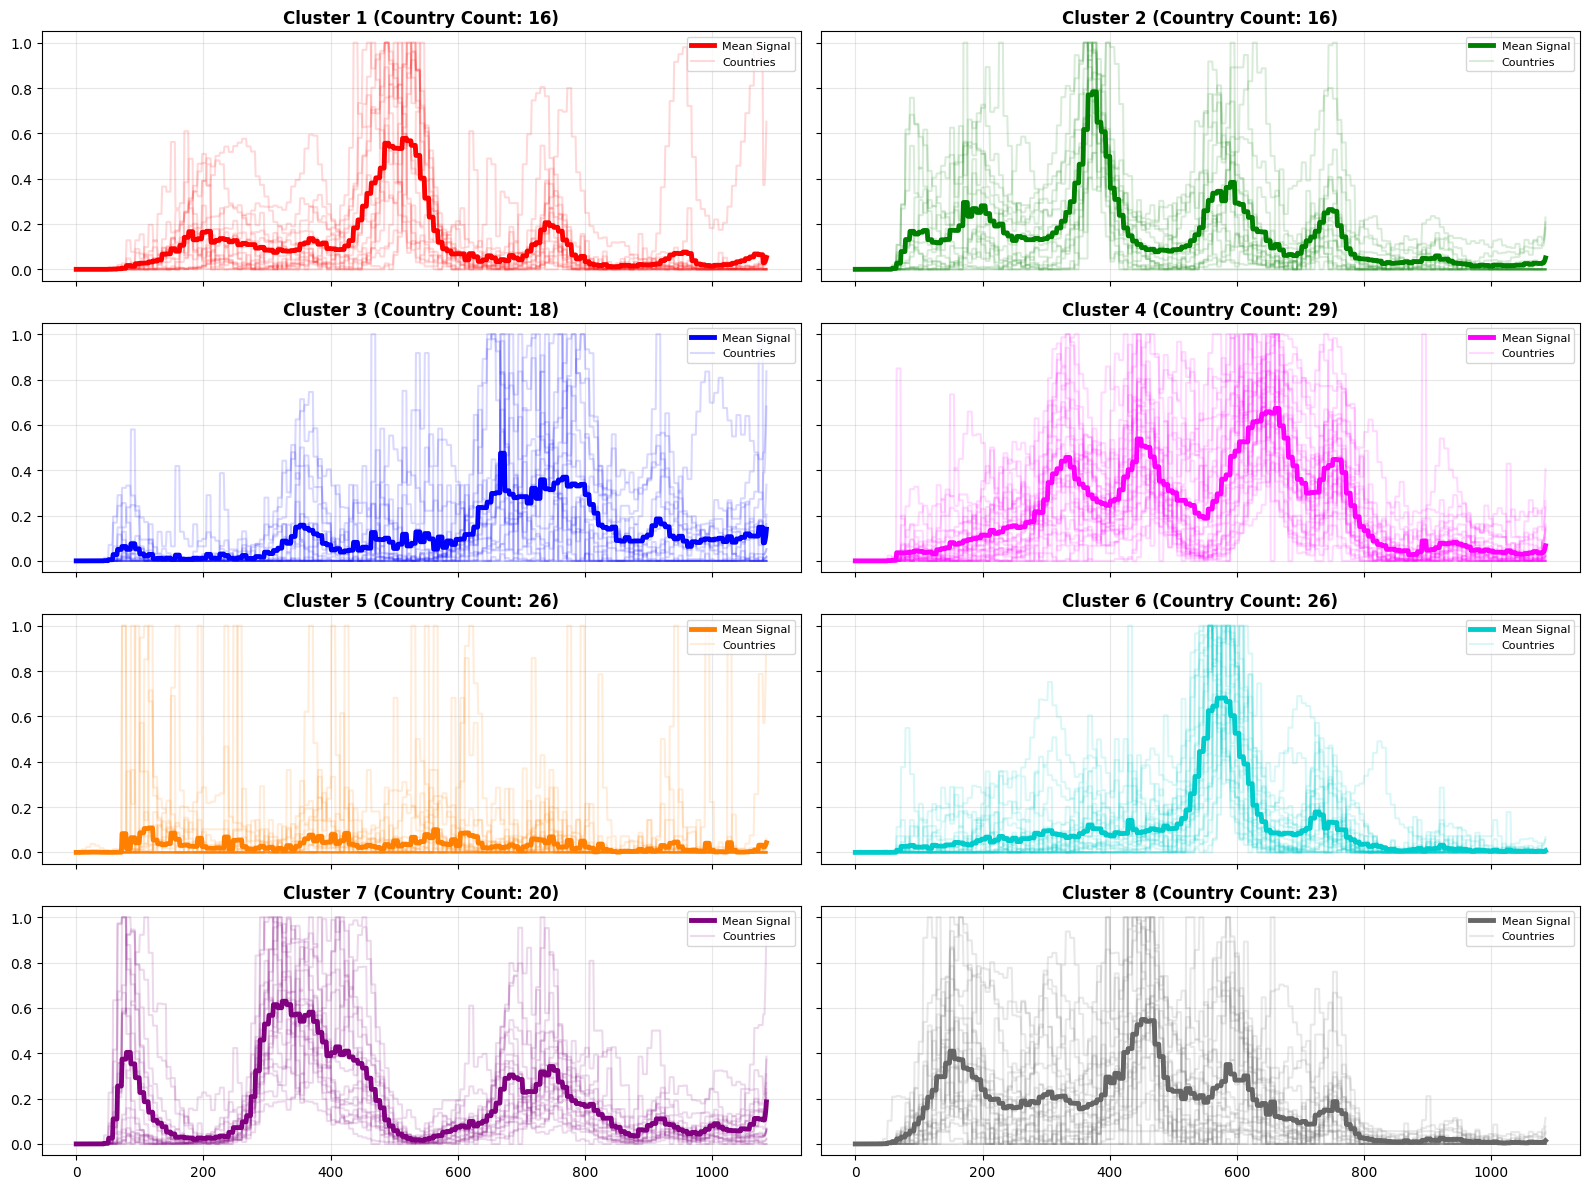

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
import plotly.express as px
import matplotlib.pyplot as plt
import urllib.request
import io
import warnings
warnings.filterwarnings("ignore")

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# =========================================================================
# 0. MASTER COUNTRY LIST (174 COUNTRIES)
# =========================================================================
master_country_list = [
    "Afghanistan", "Albania", "Algeria", "Angola", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan",
    "Bahrain", "Bangladesh", "Belarus", "Belgium", "Benin", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Bulgaria", "Burkina Faso", "Burundi", "Cambodia", "Cameroon", "Canada", "Cape Verde", "Central African Republic",
    "Chad", "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica", "Cote d'Ivoire", "Croatia", "Cuba",
    "Cyprus", "Czechia", "Democratic Republic of Congo", "Denmark", "Djibouti", "Dominican Republic", "Ecuador",
    "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia", "Finland", "France",
    "French Polynesia", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Gibraltar", "Greece", "Guatemala",
    "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hong Kong", "Hungary", "Iceland", "India", "Indonesia",
    "Iran", "Iraq", "Ireland", "Isle of Man", "Israel", "Italy", "Jamaica", "Japan", "Jordan", "Kazakhstan", "Kenya",
    "Kuwait", "Kyrgyzstan", "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Lithuania", "Luxembourg",
    "Macao", "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", "Mauritania",
    "Mauritius", "Mexico", "Micronesia (country)", "Moldova", "Mongolia", "Montenegro", "Morocco", "Mozambique",
    "Myanmar", "Namibia", "Nepal", "Netherlands", "New Caledonia", "New Zealand", "Nicaragua", "Niger", "Nigeria",
    "North Macedonia", "Norway", "Oman", "Pakistan", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines",
    "Poland", "Portugal", "Qatar", "Romania", "Russia", "Rwanda", "Sao Tome and Principe", "Saudi Arabia", "Senegal",
    "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia", "Solomon Islands", "Somalia",
    "South Africa", "South Korea", "South Sudan", "Spain", "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland",
    "Syria", "Tajikistan", "Tanzania", "Thailand", "Timor", "Togo", "Trinidad and Tobago", "Tunisia", "Turkey",
    "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom", "United States", "Uruguay", "Uzbekistan",
    "Venezuela", "Vietnam", "Yemen", "Zambia", "Zimbabwe"
]

# =========================================================================
# 1. FETCH LIVE OWID DATA
# =========================================================================
print("Fetching live OWID data...")
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
response = urllib.request.urlopen(req)
df_owid = pd.read_csv(io.StringIO(response.read().decode('utf-8')), parse_dates=['date'])

# Map target names to OWID compatible names
name_mapping = {
    "Timor": "East Timor",
    "Democratic Republic of Congo": "Democratic Republic of Congo",
    "Cote d'Ivoire": "Cote d'Ivoire",
    "Micronesia (country)": "Micronesia (country)"
}
mapped_country_list = [name_mapping.get(c, c) for c in master_country_list]

# =========================================================================
# 2. DATA PREPROCESSING & PIVOT
# =========================================================================
start_date = pd.to_datetime('2020-01-21')
end_date = pd.to_datetime('2023-01-10')

df_filtered = df_owid[
    (df_owid['location'].isin(mapped_country_list)) &
    (df_owid['date'] >= start_date) &
    (df_owid['date'] <= end_date)
][['location', 'iso_code', 'date', 'new_deaths_per_million']]

# Extract ISO codes for precise mapping
iso_map = df_filtered.drop_duplicates('location').set_index('location')['iso_code'].to_dict()

# Drop duplicate records for the same day (OWID anomalies)
df_filtered = df_filtered.drop_duplicates(subset=['location', 'date'])

# Fill NaN and negative values with 0
df_filtered['new_deaths_per_million'] = df_filtered['new_deaths_per_million'].fillna(0).clip(lower=0)

# Create a pivot table (Rows: Locations, Columns: Dates)
pivot_df = df_filtered.pivot(index='location', columns='date', values='new_deaths_per_million').fillna(0)

# 7-Day Moving Average & Min-Max Normalization
smoothed = pivot_df.rolling(window=7, axis=1, min_periods=1, center=True).mean()
min_vals = smoothed.min(axis=1)
max_vals = smoothed.max(axis=1)
max_vals[max_vals == 0] = 1 # Prevent division by zero

norm_deaths = smoothed.subtract(min_vals, axis=0).divide((max_vals - min_vals), axis=0).values
countries_final = pivot_df.index.tolist()
N, T = norm_deaths.shape
print(f"Training Data Ready: {N} Countries, {T} Time Steps")

X_tensor = torch.tensor(norm_deaths, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=True)

# =========================================================================
# 3. VAE ARCHITECTURE & TRAINING
# =========================================================================
LATENT_DIM = 8

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=8):
        super().__init__()
        self.enc_net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU())
        self.mu_layer = nn.Linear(hidden_dim // 2, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim // 2, latent_dim)
        self.dec_net = nn.Sequential(nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(), nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, input_dim), nn.Sigmoid())

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h = self.enc_net(x)
        mu, logvar = self.mu_layer(h), self.logvar_layer(h)
        return self.dec_net(self.reparametrize(mu, logvar)), mu, logvar

def vae_loss(x, x_hat, mu, logvar):
    return nn.functional.mse_loss(x_hat, x, reduction="sum") - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

model = VAE(input_dim=T, hidden_dim=128, latent_dim=LATENT_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 200

print(f"VAE Training Started ({EPOCHS} Epochs)...")
model.train()
for epoch in range(EPOCHS):
    for (batch,) in loader:
        optimizer.zero_grad()
        x_hat, mu, logvar = model(batch)
        loss = vae_loss(batch, x_hat, mu, logvar)
        loss.backward()
        optimizer.step()

# =========================================================================
# 4. K-MEANS CLUSTERING & EXCEL EXPORT
# =========================================================================
model.eval()
with torch.no_grad():
    mu_all = model.mu_layer(model.enc_net(X_tensor)).numpy()

print("Applying K-Means Clustering...")
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(mu_all) + 1

# Create dictionary for structured Excel output
cluster_dict = {f"Cluster {i}": [] for i in range(1, 9)}
reverse_mapping = {v: k for k, v in name_mapping.items()}

for country, cluster_id in zip(countries_final, clusters):
    orig_name = reverse_mapping.get(country, country)
    cluster_dict[f"Cluster {cluster_id}"].append(orig_name)

# Equalize list lengths for pandas DataFrame conversion
max_len = max(len(lst) for lst in cluster_dict.values())
for k in cluster_dict.keys():
    cluster_dict[k] += [""] * (max_len - len(cluster_dict[k]))

df_export = pd.DataFrame(cluster_dict)
df_export.to_excel("VAE_8_Clusters_Comparison.xlsx", index=False)
print("\n>>> SUCCESS: 'VAE_8_Clusters_Comparison.xlsx' saved locally!")

# =========================================================================
# 5. PLOTTING REPRESENTATIVE (MEAN) SIGNALS
# =========================================================================
print("Plotting and saving mean signals...")
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()
hex_colors = {1: "red", 2: "green", 3: "blue", 4: "magenta", 5: "#FF8000", 6: "#00CCCC", 7: "#800080", 8: "#666666"}

for i in range(1, 9):
    cluster_data = norm_deaths[clusters == i]
    if len(cluster_data) > 0:
        # Plot mean signal (thick line)
        mean_signal = cluster_data.mean(axis=0)
        axes[i-1].plot(mean_signal, color=hex_colors[i], linewidth=3.5, zorder=5, label="Mean Signal")

        # Plot all individual countries in background
        for idx, sig in enumerate(cluster_data):
            axes[i-1].plot(sig, color=hex_colors[i], alpha=0.15, label="Countries" if idx==0 else "")

    axes[i-1].set_title(f"Cluster {i} (Country Count: {len(cluster_data)})", fontweight="bold")
    axes[i-1].legend(loc="upper right", fontsize=8)
    axes[i-1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("VAE_Representative_Signals.png", dpi=150)
print(">>> SUCCESS: 'VAE_Representative_Signals.png' saved locally!")
plt.show()

# =========================================================================
# 6. GLOBAL CHOROPLETH MAP
# =========================================================================
df_map = pd.DataFrame({
    'Country': countries_final,
    'ISO_Code': [iso_map.get(c, "") for c in countries_final],
    'Cluster': clusters.astype(str)
})

colors_str = {str(k): v for k, v in hex_colors.items()}

fig = px.choropleth(
    df_map, locations="ISO_Code", locationmode='ISO-3', color="Cluster", hover_name="Country",
    color_discrete_map=colors_str, title="VAE Latent Space Clustering (K=8)", projection="natural earth"
)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

## Google Colab is available in VS Code!
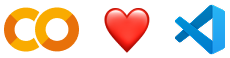

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  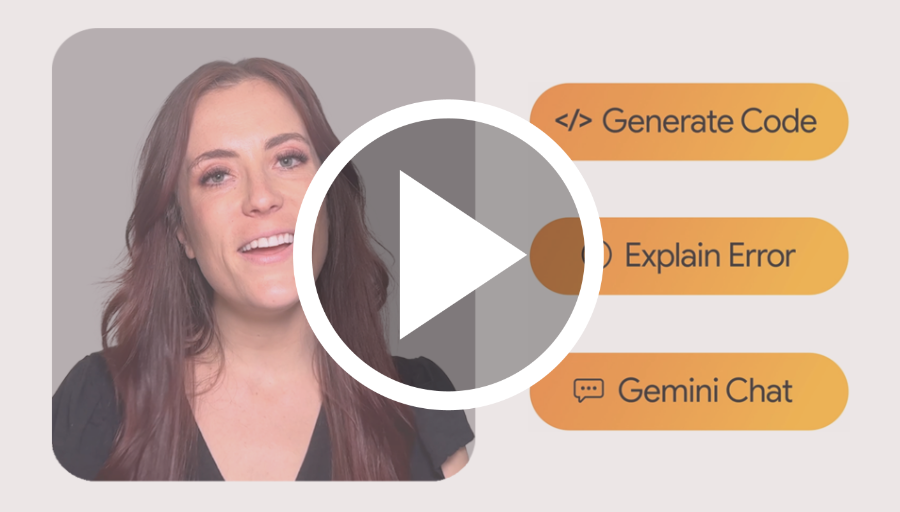
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

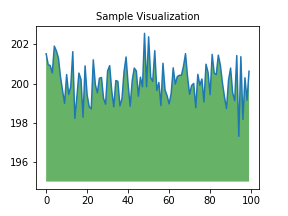

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)


OWID verisi canlı olarak indiriliyor...
Eğitim Verisi Hazır: 174 Ülke, 1086 Zaman Adımı
VAE Eğitimi Başlıyor (200 Epoch)...
Kümeleme Yapılıyor...

>>> BAŞARILI: 'VAE_8_Clusters_Kiyaslama.xlsx' Colab dosyalarına kaydedildi!
Ortalama sinyaller çiziliyor ve kaydediliyor...
>>> BAŞARILI: 'VAE_Temsili_Sinyaller.png' Colab dosyalarına kaydedildi!


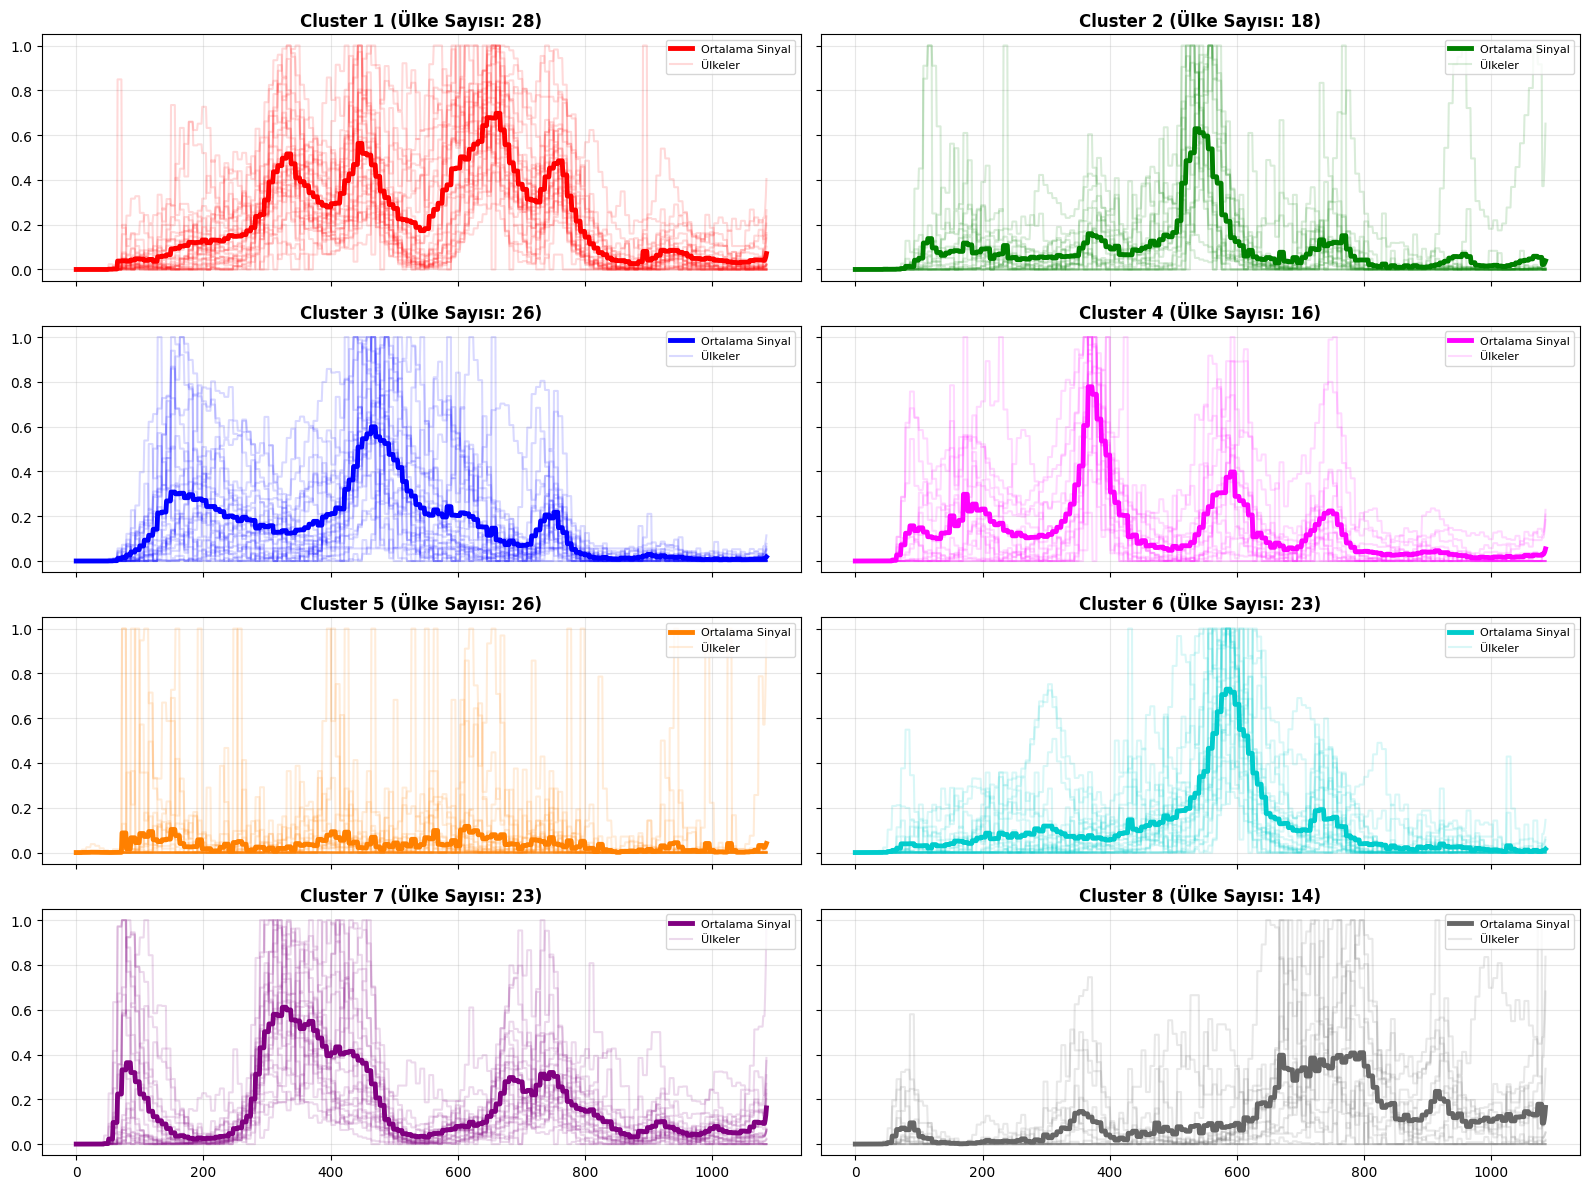

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
import plotly.express as px
import matplotlib.pyplot as plt
import urllib.request
import io
import warnings
warnings.filterwarnings("ignore")

# Tekrarlanabilirlik
np.random.seed(42)
torch.manual_seed(42)

# =========================================================================
# 0. 174 ÜLKELİK MASTER LİSTE
# =========================================================================
master_country_list = [
    "Afghanistan", "Albania", "Algeria", "Angola", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan",
    "Bahrain", "Bangladesh", "Belarus", "Belgium", "Benin", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Bulgaria", "Burkina Faso", "Burundi", "Cambodia", "Cameroon", "Canada", "Cape Verde", "Central African Republic",
    "Chad", "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica", "Cote d'Ivoire", "Croatia", "Cuba",
    "Cyprus", "Czechia", "Democratic Republic of Congo", "Denmark", "Djibouti", "Dominican Republic", "Ecuador",
    "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia", "Finland", "France",
    "French Polynesia", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Gibraltar", "Greece", "Guatemala",
    "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hong Kong", "Hungary", "Iceland", "India", "Indonesia",
    "Iran", "Iraq", "Ireland", "Isle of Man", "Israel", "Italy", "Jamaica", "Japan", "Jordan", "Kazakhstan", "Kenya",
    "Kuwait", "Kyrgyzstan", "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Lithuania", "Luxembourg",
    "Macao", "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", "Mauritania",
    "Mauritius", "Mexico", "Micronesia (country)", "Moldova", "Mongolia", "Montenegro", "Morocco", "Mozambique",
    "Myanmar", "Namibia", "Nepal", "Netherlands", "New Caledonia", "New Zealand", "Nicaragua", "Niger", "Nigeria",
    "North Macedonia", "Norway", "Oman", "Pakistan", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines",
    "Poland", "Portugal", "Qatar", "Romania", "Russia", "Rwanda", "Sao Tome and Principe", "Saudi Arabia", "Senegal",
    "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia", "Solomon Islands", "Somalia",
    "South Africa", "South Korea", "South Sudan", "Spain", "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland",
    "Syria", "Tajikistan", "Tanzania", "Thailand", "Timor", "Togo", "Trinidad and Tobago", "Tunisia", "Turkey",
    "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom", "United States", "Uruguay", "Uzbekistan",
    "Venezuela", "Vietnam", "Yemen", "Zambia", "Zimbabwe"
]

# =========================================================================
# 1. OWID VERİSİNİ CANLI OLARAK ÇEKME
# =========================================================================
print("OWID verisi canlı olarak indiriliyor...")
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
response = urllib.request.urlopen(req)
df_owid = pd.read_csv(io.StringIO(response.read().decode('utf-8')), parse_dates=['date'])

# İsim Eşleştirme (Senin Listendeki -> OWID Formatına)
name_mapping = {
    "Timor": "East Timor",
    "Democratic Republic of Congo": "Democratic Republic of Congo",
    "Cote d'Ivoire": "Cote d'Ivoire",
    "Micronesia (country)": "Micronesia (country)"
}
mapped_country_list = [name_mapping.get(c, c) for c in master_country_list]

# =========================================================================
# 2. VERİ ÖN İŞLEME VE PİVOT
# =========================================================================
start_date = pd.to_datetime('2020-01-21')
end_date = pd.to_datetime('2023-01-10')

df_filtered = df_owid[
    (df_owid['location'].isin(mapped_country_list)) &
    (df_owid['date'] >= start_date) &
    (df_owid['date'] <= end_date)
][['location', 'iso_code', 'date', 'new_deaths_per_million']]

# ISO Kodlarını Harita İçin Alalım
iso_map = df_filtered.drop_duplicates('location').set_index('location')['iso_code'].to_dict()

# Çift kayıt hatasını çözen filtre
df_filtered = df_filtered.drop_duplicates(subset=['location', 'date'])

df_filtered['new_deaths_per_million'] = df_filtered['new_deaths_per_million'].fillna(0).clip(lower=0)
pivot_df = df_filtered.pivot(index='location', columns='date', values='new_deaths_per_million').fillna(0)

# Hareketli ortalama ve Min-Max Normalizasyon
smoothed = pivot_df.rolling(window=7, axis=1, min_periods=1, center=True).mean()
min_vals = smoothed.min(axis=1)
max_vals = smoothed.max(axis=1)
max_vals[max_vals == 0] = 1

norm_deaths = smoothed.subtract(min_vals, axis=0).divide((max_vals - min_vals), axis=0).values
countries_final = pivot_df.index.tolist()
N, T = norm_deaths.shape
print(f"Eğitim Verisi Hazır: {N} Ülke, {T} Zaman Adımı")

X_tensor = torch.tensor(norm_deaths, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=True)

# =========================================================================
# 3. VAE MİMARİSİ VE EĞİTİM
# =========================================================================
LATENT_DIM = 8

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=8):
        super().__init__()
        self.enc_net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU())
        self.mu_layer = nn.Linear(hidden_dim // 2, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim // 2, latent_dim)
        self.dec_net = nn.Sequential(nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(), nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, input_dim), nn.Sigmoid())

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h = self.enc_net(x)
        mu, logvar = self.mu_layer(h), self.logvar_layer(h)
        return self.dec_net(self.reparametrize(mu, logvar)), mu, logvar

def vae_loss(x, x_hat, mu, logvar):
    return nn.functional.mse_loss(x_hat, x, reduction="sum") - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

model = VAE(input_dim=T, hidden_dim=128, latent_dim=LATENT_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 200

print(f"VAE Eğitimi Başlıyor ({EPOCHS} Epoch)...")
model.train()
for epoch in range(EPOCHS):
    for (batch,) in loader:
        optimizer.zero_grad()
        x_hat, mu, logvar = model(batch)
        loss = vae_loss(batch, x_hat, mu, logvar)
        loss.backward()
        optimizer.step()

# =========================================================================
# 4. K-MEANS VE İSTENİLEN FORMATTA EXCEL ÇIKTISI
# =========================================================================
model.eval()
with torch.no_grad():
    mu_all = model.mu_layer(model.enc_net(X_tensor)).numpy()

print("Kümeleme Yapılıyor...")
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(mu_all) + 1

# Sütun başlıkları "Cluster 1, Cluster 2..." olan bir sözlük oluştur
cluster_dict = {f"Cluster {i}": [] for i in range(1, 9)}

# Orijinal (Senin) isimlerini geri getirme
reverse_mapping = {v: k for k, v in name_mapping.items()}

# Ülkeleri kendi kümelerinin listesine ekle
for country, cluster_id in zip(countries_final, clusters):
    orig_name = reverse_mapping.get(country, country)
    cluster_dict[f"Cluster {cluster_id}"].append(orig_name)

# Excel'de düzgün durması için tüm listelerin boyunu en uzun kümeye eşitle (boşluk ekle)
max_len = max(len(lst) for lst in cluster_dict.values())
for k in cluster_dict.keys():
    cluster_dict[k] += [""] * (max_len - len(cluster_dict[k]))

# EXCEL OLARAK KAYDET
df_export = pd.DataFrame(cluster_dict)
df_export.to_excel("VAE_8_Clusters_Kiyaslama.xlsx", index=False)
print("\n>>> BAŞARILI: 'VAE_8_Clusters_Kiyaslama.xlsx' Colab dosyalarına kaydedildi!")

# =========================================================================
# 5. TEMSİLİ (ORTALAMA) SİNYALLERİ ÇİZME
# =========================================================================
print("Ortalama sinyaller çiziliyor ve kaydediliyor...")
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()
hex_colors = {1: "red", 2: "green", 3: "blue", 4: "magenta", 5: "#FF8000", 6: "#00CCCC", 7: "#800080", 8: "#666666"}

for i in range(1, 9):
    cluster_data = norm_deaths[clusters == i]
    if len(cluster_data) > 0:
        # Temsili (Ortalama) Sinyal - Kalın Çizgi
        mean_signal = cluster_data.mean(axis=0)
        axes[i-1].plot(mean_signal, color=hex_colors[i], linewidth=3.5, zorder=5, label="Ortalama Sinyal")

        # O kümedeki tüm diğer ülkeler - Arka planda silik
        for idx, sig in enumerate(cluster_data):
            axes[i-1].plot(sig, color=hex_colors[i], alpha=0.15, label="Ülkeler" if idx==0 else "")

    axes[i-1].set_title(f"Cluster {i} (Ülke Sayısı: {len(cluster_data)})", fontweight="bold")
    axes[i-1].legend(loc="upper right", fontsize=8)
    axes[i-1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("VAE_Temsili_Sinyaller.png", dpi=150)
print(">>> BAŞARILI: 'VAE_Temsili_Sinyaller.png' Colab dosyalarına kaydedildi!")
plt.show()

# =========================================================================
# 6. DÜNYA HARİTASI
# =========================================================================
df_map = pd.DataFrame({
    'Country': countries_final,
    'ISO_Code': [iso_map.get(c, "") for c in countries_final],
    'Cluster': clusters.astype(str)
})

colors_str = {str(k): v for k, v in hex_colors.items()}

fig = px.choropleth(
    df_map, locations="ISO_Code", locationmode='ISO-3', color="Cluster", hover_name="Country",
    color_discrete_map=colors_str, title="VAE Latent Space Kümeleme (K=8)", projection="natural earth"
)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()